### So far for your course project -
You should have -


1.  Your team, your preferred way of communicating
2.  Your topic chosen
3.  A machine, either on campus or personally owned, where you can do your experiments.  There are three lab machines in Congdon 2035.  Students who requested card access to Congdon 2035 should have it already.
4.  Software that you can host and run a smaller-sized LLM (Llama 3 7B version as an example).
5. Downloaded and tested an LLM locally.
6.  The links of the knowledge you want to provide to your chatbot to learn from.


### What if my teammates do not respond -

1.  Please keep a record of the communications (like emails) you have sent.
2.  Then, continue with the rest of the teammates who are willing to work on the project and try your best to make progress happen, even if it means you are working by yourself.
3.  As a final report, your team will do a report as a team, and then, each of you will report on your effort as an individual report.  The syllabus says the course project accounts for 20% of the course final grade.


### Now, if you have a teammate you have not connected to so far, Dr. Song will pass around the microphone so you can ask him/her to talk to you right after this lecture.

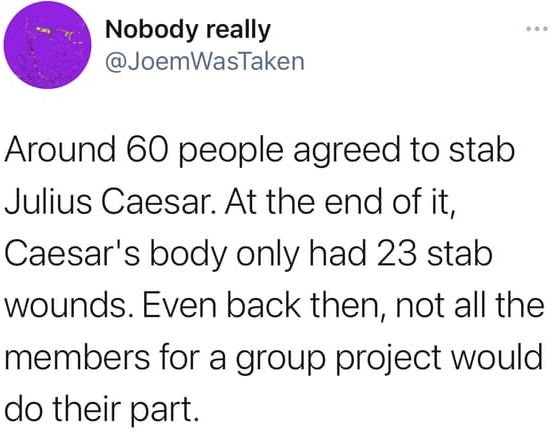

### Retrieval Augmented Generation (RAG)

Retrieval-augmented generation is a technique for enhancing the *accuracy and reliability* of generative AI models with information fetched from specific and relevant data sources.

In other words, it fills a gap in how LLMs work. Under the hood, LLMs are neural networks, typically measured by how many parameters they contain. An LLM’s parameters essentially represent the general patterns of how humans use words to form sentences.

That deep understanding, sometimes called parameterized knowledge, makes LLMs useful in responding to general prompts. However, when users need authoritative, source-grounded answers rather than broad knowledge alone, RAG can provide the necessary depth and accuracy.

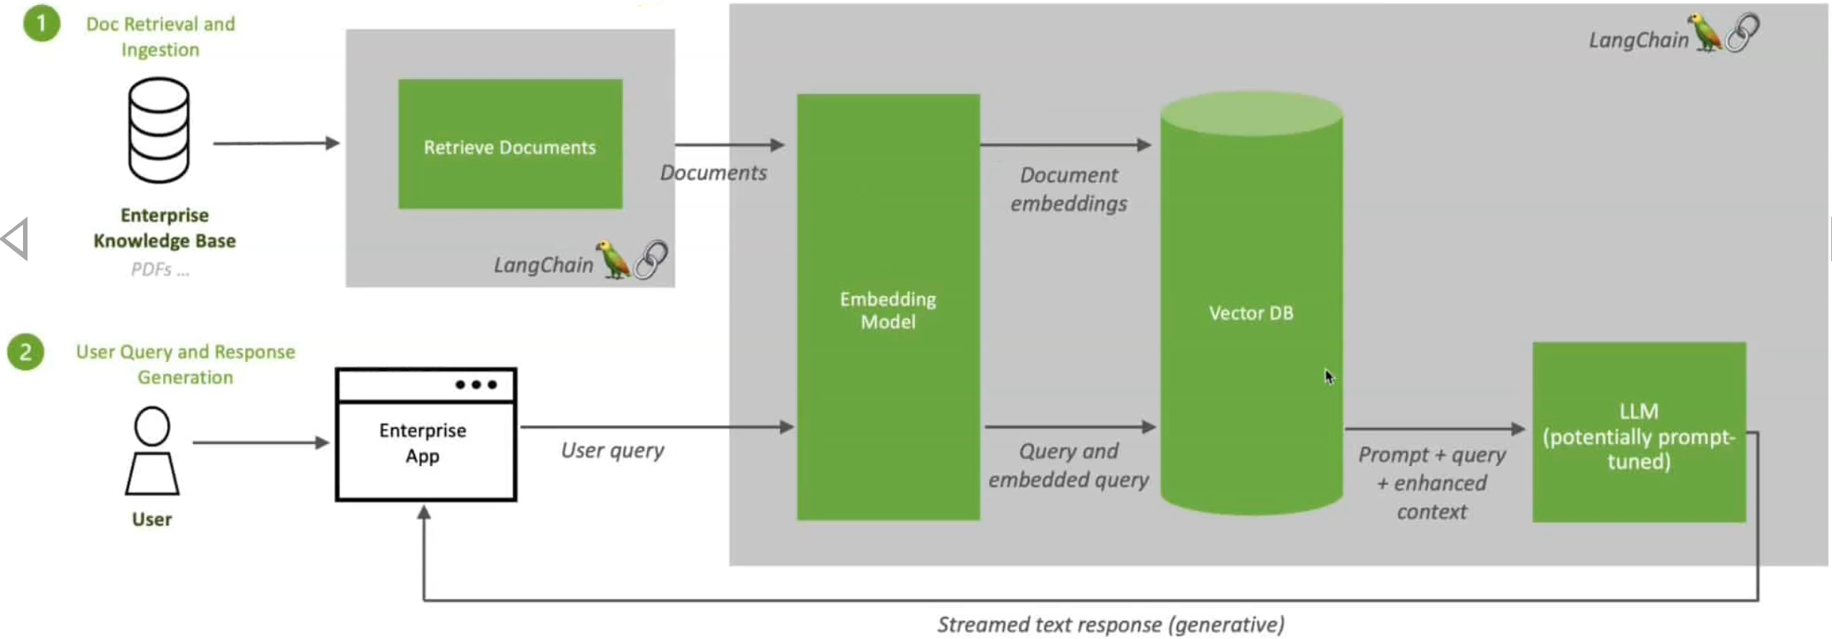

#### Vector database and Embedding

Unlike a traditional relational database, a **vector database** is designed to efficiently handle and retrieve vector embeddings of complex data types like images, videos, and audio. This makes them particularly suited for advanced search capabilities and AI-driven data analysis.

Classically, when people thought of “data,” they thought of *spreadsheets and charts*. This is what we now call structured data, and it only makes up a very small fraction of the data we have access to these days. This type of data fits well in a traditional database. But all the unstructured data, things like images and blog posts, where there are no neat tables of columns and rows.

A **vector database** is a type of database designed for this very purpose: it not only stores unstructured data like images and blog posts but also the vector embeddings of these items. Through a process called vectorization, we can transform complex, high-dimensional unstructured data into a lower-dimensional, numerical form that captures the essence of the data and then store each vector. These vector embeddings capture a huge amount of information about whatever piece of data they’re representing. The process of vectorization also normalizes your data, meaning that each vector you store will have the same dimensionality.

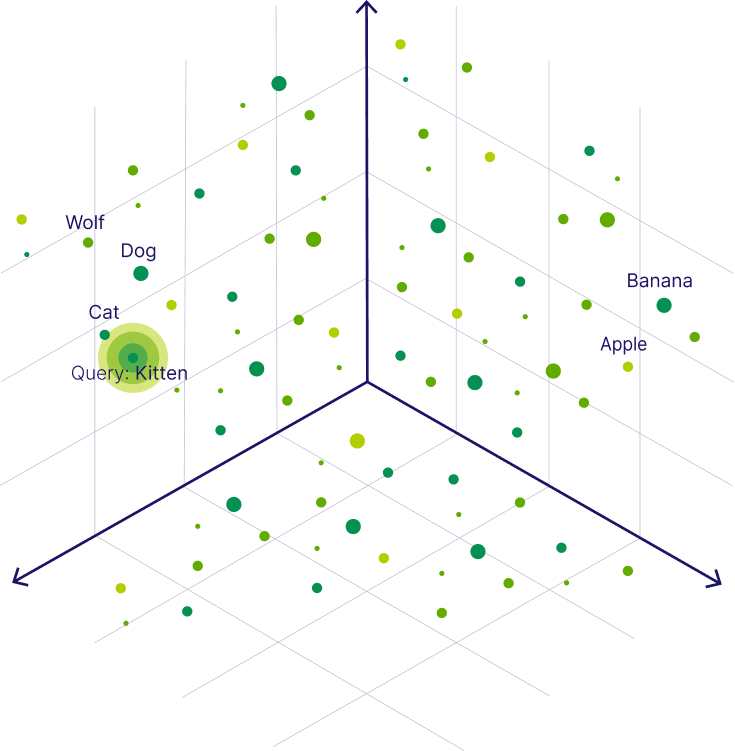

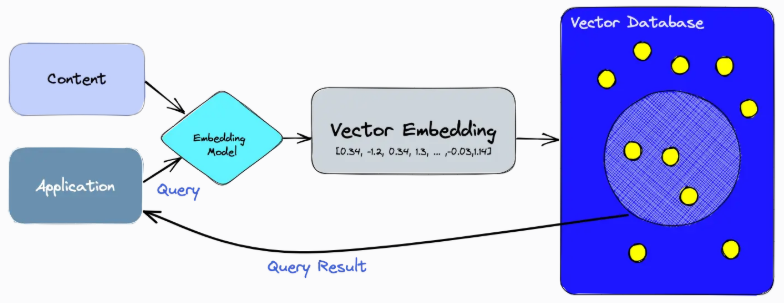

Let’s break the RAG process down:

*  First, we use the embedding model to create vector embeddings for the content we want to index.
*  The vector embedding is inserted into the vector database, with some reference to the original content the embedding was created from.
*  When the application issues a query, we use the same embedding model to create embeddings for the query and use those embeddings to query the database for similar vector embeddings. As mentioned before, those similar embeddings are associated with the original content that was used to create them.

#### So, what is role prompting, and why does role prompting work?

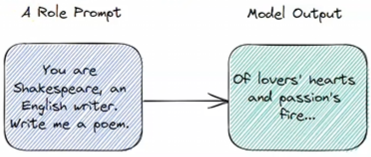

**Role prompting** is a technique that involves assigning a role or persona to an AI model, such as "food critic" or "mathematician," to control the style1 or accuracy of its responses.

By instructing the model to take on a specific role, you can shape how it processes and delivers information. This technique is widely used across many applications, from creative writing to problem-solving.

##### Try this in-class -
Find a LLM you have access to, and try create a dialog with this prompt first -

`Write a positive review of [pizza place].`

Then do a comparision with a new dialog with this prompt -

`You are a food critic. Write a positive review of [pizza place].`

Do you see the difference?

#### Embedding models
A vector database is designed to store vector data. But vector data isn’t something that can just be made up, it’s something that is generated via machine learning. There are plenty of machine learning models that **convert unstructured data into vectors** (they are called **embedding models**); some are large language models to process text like descriptions and blog posts while others are vision models that create vector embeddings for images and videos.

Vector databases are optimized to store these vectors and to allow users to efficiently organize, search, and analyze this complex information in ways that traditional databases can’t. These databases use the embeddings to find the similarity between vectors, and in turn to power similarity search over the vectors being stored. There are different ways that we can calculate this similarity, such as Euclidean distance and cosine similarity.

In our class and join-class projects, we will only use text embedding models.

From the tools we use, we have many choices -

Vector databases -

*   LanceDB (with AnythingLLM)
*   Pinecone
*   Chroma





### Crawling Webpages

Most of the webpages are designed to be visually pleasant, but not necessarily for training LLMs. You have many choices -


*  Anything LLM has a crawler feature. You can add hyperlinks to Anything LLM, and it will crawl the content for you. But it's hard for you to see the raw data this way.
*  You can manually copy the textual content from the webpages. You can do some "cleaning" when you are doing this.
*  Some professional crawler tools (like [FireCrawl](https://www.firecrawl.dev/)) can crawl webpages better in a machine-understandable format (markdown or JSON).
 * You can do experiments and try what works best.

### Parsing PDF files.

Raw PDF data often includes irrelevant elements like headers, footers, page numbers, or tables of contents, which clutter training data. Parsing removes this, ensuring the LLM focuses on valuable content. Here are some choices for parsing PDFs -
*  [Claude](https://claude.ai/) has a free PDF parsing agent (free, but you will need an account)
*  [LlamaParse](https://cloud.llamaindex.ai/) is another online tool that you can upload a PDF and receive its markdown version.

Please note that the images are very likely to be excluded from the PDF parsing.

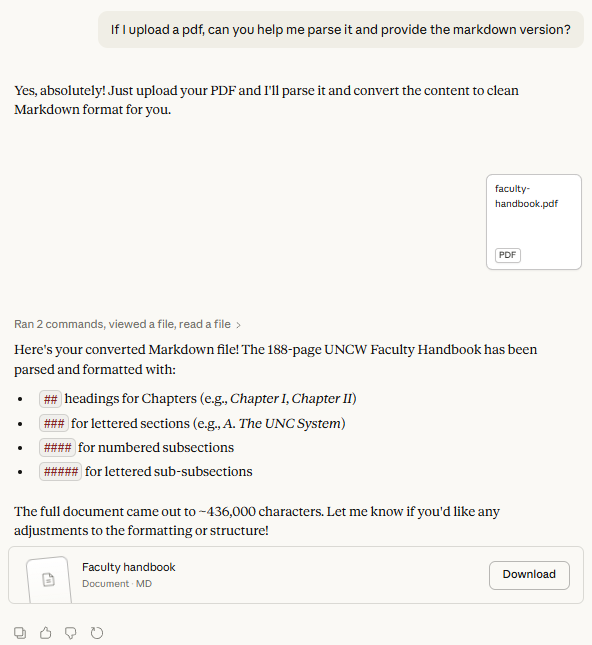

### Chunking and Overlap

Chunking in LLMs breaks large documents into smaller, manageable, and semantically relevant pieces to fit within the model's limited context window and improve retrieval accuracy. Overlap ensures that information cut off at the boundary of one chunk is retained in the next, maintaining context, reducing fragmentation, and improving search performance.

Recommended Starting Points for Llama -
*    General Purpose: 500-1k tokens with a 10% overlap (approx. 50–100 tokens).
    *  This is widely considered the "sweet spot" for balancing retrieval accuracy with context preservation.
*    Fact-Based Queries: 256–512 tokens.
    *   Smaller chunks are better for pinpointing specific facts, dates, or names without extra "noise".
    *   "what's the GPU model in Dell Pro Max with GB10?"  (consider [this](https://www.dell.com/en-us/shop/cty/pdp/spd/dell-pro-max-fcm1253-micro/xcto_fcm1253_usx?redirectTo=SOC&tfcid=91049735&&gacd=9684992-1105-5761040-266906002-0&dgc=ST&SA360CID=22394684528&gclsrc=aw.ds&gad_source=1&gad_campaignid=22394684528&gbraid=0AAAAADllXQdJNWp83eK06LIUha3ASlKJM&gclid=CjwKCAiAkvDMBhBMEiwAnUA9BUOJzxONQ84ocIegA2WGUhQcSQxF-sAjAugz6eZQUf26zey5HBRd1hoC0iEQAvD_BwE) as knowledge source)   

*    Analytical/Complex Queries: 1024+ tokens.
    *   If your queries require Llama to synthesize information across multiple paragraphs or explain a process, larger chunks are necessary to keep the context intact.
    *   "How do you define the relationship between Harry Potter and Luna Lovegood?"


### After the lecture today -

*  Prepare your input knowledge.
*  Crawl, parse and format your knowledge base and feed it into your chatbot.
*  Experiment with system prompt, chunk size
*  Develope a set of testing questions, at least your charbot should be able to answer the questions directly presented in the input knowledge base.


### Final recommendations -

1)   You can also use third-party crawler tools to crawl a certain website. There are many of this type of crawlers that you don't need to code, and you will have better configuration choices. ([Firecrawl](https://www.firecrawl.dev/) was once used by Dr. Song's students in another project.)
2)   The input file type could make a difference. With the same content, four chatbots, one with a .pdf file, one with .md, one with .json, and one with a .txt file, could perform quite differently in practice. (You can experiment and find which performs better this week.)
3)   Your instructor cannot give you a set of perfect configurations/parameters for your chatbot. You will need to experiment -


 *  Your base LLM model
 *  System-level prompt
 *  The way you prepare your data as input (.md? .txt? or your own way of structuring your input)
 *  Chunk size and overlap
 *  Embedding model to pick
 *  Vector database to pick

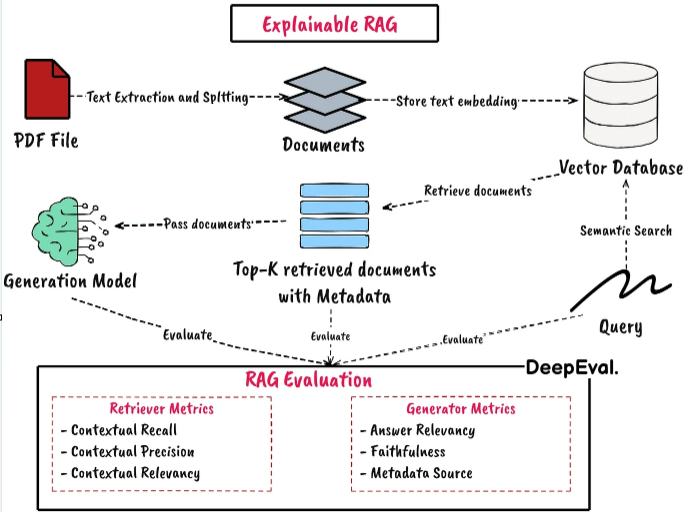